# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your repo is stored elsewhere in Drive.
PROJECT_ROOT = "/content/drive/MyDrive/Assignment1_2026"

Mounted at /content/drive


In [ ]:
# Install Python dependencies (run once per session)
!pip install -r {PROJECT_ROOT}/requirements.txt -q
!python -m spacy download en
!pip install ujson -q


---
## Section 0 — Environment Setup

Mount Google Drive and install dependencies.

In [ ]:
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/Assignment1_2026


---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists on your Drive, delete this section before submission.

In [ ]:
from Tools.download import download_mini

download_mini(data_dir="_data")

Step 1 / 2  —  Mini dataset (SQuAD + GloVe)
  [skip] Mini dataset already present in _data/.

Step 2 / 2  —  spaCy language model
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 148.0 MB/s eta 0:00:00
⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Mini dataset download complete.


---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists on your Drive, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [ ]:
!pip install ujson -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.3 MB/s eta 0:00:00


In [ ]:
from Tools.preproc import preprocess

preprocess(
    train_file="_data/squad/train-mini.json",
    dev_file="_data/squad/dev-v1.1.json",
    glove_word_file="_data/glove/glove.mini.txt",
    target_dir="_data",
    para_limit=400,
    ques_limit=50,
)

Generating train examples…


100%|██████████| 150/150 [00:05<00:00, 28.71it/s]


  30293 questions in total
Generating dev examples…


100%|██████████| 48/48 [00:01<00:00, 25.83it/s]


  10570 questions in total
Generating word embedding…


...

100%|██████████| 30293/30293 [00:07<00:00, 3847.55it/s]


  Built 30169 / 30293 instances
Processing dev examples…


100%|██████████| 10570/10570 [00:03<00:00, 3493.76it/s]


  Built 10465 / 10570 instances
Saving word embedding…
Saving char embedding…
Saving train eval…
Saving dev eval…
Saving word dictionary…
Saving char dictionary…
Saving dev meta…

Preprocessing complete.
  Outputs → _data/


{'train_record_file': '_data/train.npz',
 'dev_record_file': '_data/dev.npz',
 'word_emb_file': '_data/word_emb.json',
 'char_emb_file': '_data/char_emb.json',
 'train_eval_file': '_data/train_eval.json',
 'dev_eval_file': '_data/dev_eval.json',
 'word2idx_file': '_data/word2idx.json',
 'char2idx_file': '_data/char2idx.json',
 'dev_meta_file': '_data/dev_meta.json'}

---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.


In [ ]:
#可视化函数
import matplotlib.pyplot as plt

def plot_training_history(history, title="Training Curve"):
    steps      = [h["step"]       for h in history]
    train_loss = [h["train_loss"] for h in history]
    dev_loss   = [h["dev_loss"]   for h in history]
    dev_f1     = [h["dev_f1"]     for h in history]
    dev_em     = [h["dev_em"]     for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13)

    ax1.plot(steps, train_loss, label="Train Loss", marker="o", markersize=4)
    ax1.plot(steps, dev_loss,   label="Dev Loss",   marker="s", markersize=4)
    ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
    ax1.set_title("Loss vs. Step"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(steps, dev_f1, label="Dev F1", marker="o", markersize=4)
    ax2.plot(steps, dev_em, label="Dev EM", marker="s", markersize=4)
    ax2.set_xlabel("Step"); ax2.set_ylabel("Score")
    ax2.set_title("Dev F1 / EM vs. Step"); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Experiment 1 — Effect of Optimizer: SGD vs SGD with Momentum

**Research Question:** Does adding momentum to SGD improve QANet's convergence speed and final performance on SQuAD?

**Hypothesis:** SGD with momentum should converge faster and achieve better performance than vanilla SGD because momentum accumulates gradient history, accelerating updates in consistent directions and dampening oscillations.

**Setup:** All hyperparameters are fixed. Only `optimizer_name` changes between runs.

| Setting | Value |
|---------|-------|
| scheduler | cosine |
| learning_rate | 0.01 |
| weight_decay | 3e-7 |
| dropout | 0.1 |
| num_steps | 60000 |
| seed | 42 |

- **Exp 1a:** `optimizer_name = "sgd"` (no momentum)
- **Exp 1b:** `optimizer_name = "sgd_momentum"`, `momentum = 0.9`
**Evaluation metrics:** Best F1, Best EM, training loss, convergence speed (steps to early stop).

In [ ]:
#SGD without Momentum
from TrainTools.train import train

results_exp1a = train(
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model_exp1a",
    log_dir         = "_log_exp1a",

    num_steps  = 60000,
    batch_size = 8,
    seed       = 42,

    optimizer_name = "sgd",
    scheduler_name = "cosine",
    loss_name      = "qa_nll",

    learning_rate = 0.01,
    momentum      = 0.9,
    weight_decay  = 3e-7,

    dropout       = 0.1,
    dropout_char  = 0.05,

    early_stop    = 15,
)

print(f"[Exp 1a - SGD]  Best F1: {results_exp1a['best_f1']:.4f}  |  Best EM: {results_exp1a['best_em']:.4f}")

100%|██████████| 200/200 [00:45<00:00,  4.39it/s]


STEP      200  loss 546.392102



100%|██████████| 150/150 [00:09<00:00, 16.40it/s]


VALID(train) loss 14.089065  F1 6.890788  EM 0.083333



100%|██████████| 150/150 [00:09<00:00, 16.52it/s]


...

STEP     9600  loss 13.926081



100%|██████████| 150/150 [00:09<00:00, 16.43it/s]


VALID(train) loss 4.796165  F1 6.988765  EM 0.750000



100%|██████████| 150/150 [00:09<00:00, 16.54it/s]


TEST        loss 4.864656  F1 6.343988  EM 0.500000

Learning rate: [0.009381533400219317]
Early stopping triggered.
Training finished.  Best F1: 6.8875  Best EM: 1.7500
[Exp 1a - SGD]  Best F1: 6.8875  |  Best EM: 1.7500


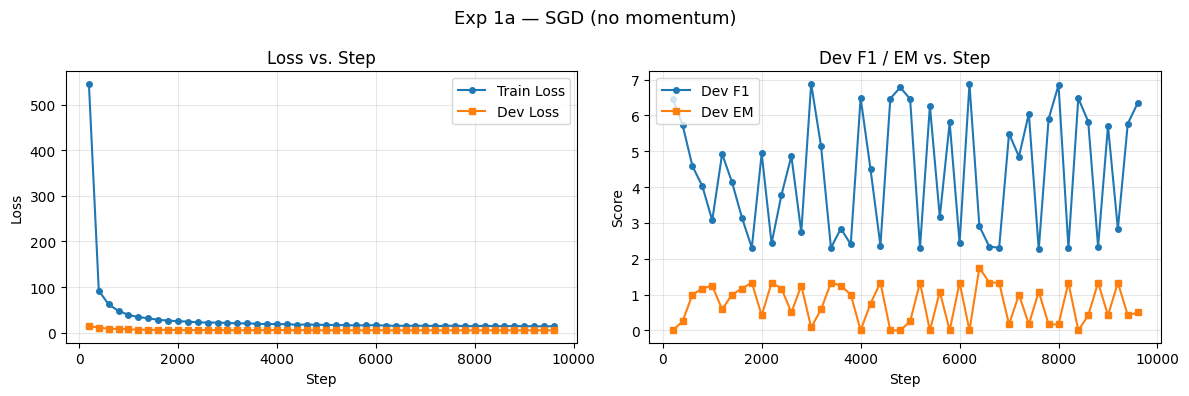

In [ ]:
plot_training_history(results_exp1a["history"], title="Exp 1a — SGD (no momentum)")

In [ ]:
# SGD + Momentum (收敛太慢)
from TrainTools.train import train

results_exp1b = train(
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model_exp1b",
    log_dir         = "_log_exp1b",

    num_steps  = 60000,
    batch_size = 8,
    seed       = 42,

    optimizer_name = "sgd_momentum",
    scheduler_name = "cosine",
    loss_name      = "qa_nll",

    learning_rate = 0.01,
    momentum      = 0.9,
    weight_decay  = 3e-7,

    dropout       = 0.1,
    dropout_char  = 0.05,

    early_stop    = 15,
)

print(f"[Exp 1b - SGD+Momentum]  Best F1: {results_exp1b['best_f1']:.4f}  |  Best EM: {results_exp1b['best_em']:.4f}")

In [ ]:
plot_training_history(results_exp1b["history"], title="Exp 1b — SGD + Momentum")

---
## Experiment 2 — Effect of Normalization: Layer Norm vs Group Norm

**Research Question:** Does the choice of normalization method (Layer Norm vs Group Norm) affect QANet's training stability and final performance on SQuAD?

**Hypothesis:** Layer Norm is better suited for NLP tasks because it normalizes across the feature dimension independently for each token, while Group Norm may introduce inter-channel dependencies that are less appropriate for sequence models.

**Setup:** All hyperparameters are identical to the stable baseline (Run 3: SGDMomentum + Cosine). Only `norm_name` is changed between runs.

- **Exp 2a (Baseline):** `norm_name = "layer_norm"` — results from Run 3
- **Exp 2b (Treatment):** `norm_name = "group_norm"`, `norm_groups = 8`

**Evaluation metrics:** Best F1, Best EM, training loss curve, convergence speed.

In [ ]:
# Experiment 2b — Group Norm
# All settings identical to Run 3 baseline; only norm_name changes.
from TrainTools.train import train

results_exp2b = train(
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model_exp2b",
    log_dir         = "_log_exp2b",

    num_steps  = 60000,
    batch_size = 8,
    seed       = 42,

    optimizer_name = "sgd_momentum",
    scheduler_name = "cosine",
    loss_name      = "qa_nll",

    learning_rate = 0.01,
    momentum      = 0.9,
    weight_decay  = 3e-7,
    dropout       = 0.1,
    dropout_char  = 0.05,
    early_stop    = 15,

    # ── Only change: Group Norm ──────────────────────────────────────────
    norm_name   = "group_norm",
    norm_groups = 8,
)

print(f"[Exp 2b - GroupNorm]  Best F1: {results_exp2b['best_f1']:.4f}  |  Best EM: {results_exp2b['best_em']:.4f}")

100%|██████████| 200/200 [00:49<00:00,  4.05it/s]


STEP      200  loss 383.849233



100%|██████████| 150/150 [00:09<00:00, 15.38it/s]


VALID(train) loss 25.650872  F1 6.561309  EM 0.000000



100%|██████████| 150/150 [00:09<00:00, 15.47it/s]


...

STEP    19800  loss 35.751356



100%|██████████| 150/150 [00:09<00:00, 15.61it/s]


VALID(train) loss 12.064892  F1 9.346667  EM 1.500000



100%|██████████| 150/150 [00:09<00:00, 15.59it/s]


TEST        loss 14.043460  F1 8.255748  EM 0.833333

Learning rate: [0.0075452070787518566]
Early stopping triggered.
Training finished.  Best F1: 9.3495  Best EM: 2.5000
[Exp 2b - GroupNorm]  Best F1: 9.3495  |  Best EM: 2.5000


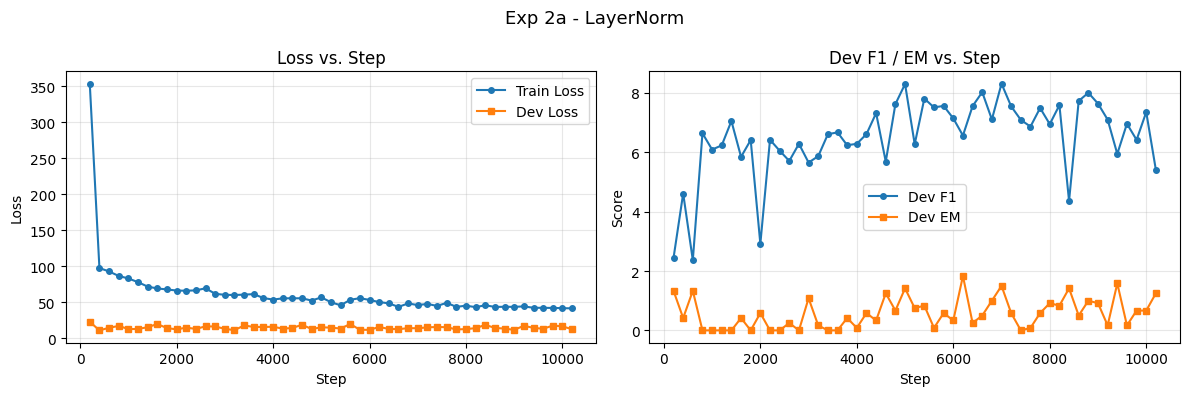

In [ ]:
plot_training_history(results["history"], "Exp 2a - LayerNorm")

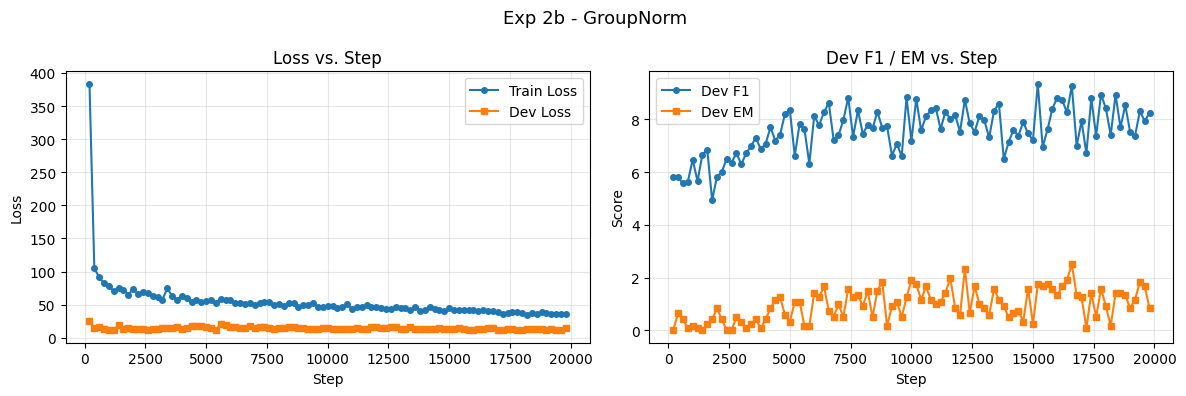

In [ ]:
plot_training_history(results_exp2b["history"], "Exp 2b - GroupNorm")

---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [ ]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model_exp1b",
    log_dir       = "_log_exp1b",
    ckpt_name     = "model.pt",
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")